In [15]:
import pandas as pd
import numpy as np
import seaborn as sns                      
import matplotlib.pyplot as plt            
%matplotlib inline
sns.set(color_codes=True)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Разведочный анализ данных

В самом начале посмотрим на содержание датасета: столбцы, их загаловки и данные

In [4]:
df = pd.read_csv('student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Затем посмотрим на типы данных, количество значений в каждом столбце и наличие пропусков

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


Типы данных: bool(1), float64(4), int64(4), object(2). При этом датасет "идеальный" - в нем нет нулевых значений и пропусков

Посмотрим на значения в датасете более подробно: узнаем минимальные и максимальные значения в столбцах

In [6]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


Значения Age варьируются от 18 до 24 - значит, все значения в норме. То же касается Sleep Duration - от 1.5 до 12 часов, Study Hours - от 0 до 12.8 часов, Social Media Hours - от 0 до 10 часов, Physical Activity - от 0 до 149 минут. Все эти значения адекватные, значит в каждом из этих столбцов нет аномалий. При этом может быть такое, что сумма этих значений будет превышать 24 часа за одни сутки - уберем такие строки в следующем блоке кода

Поработаем с датасетом: уберем колонку с ID студентов (ID не будут влиять на результаты исследований), изменим названия колонок для удобства. удалим дубликаты, а также удалим строки, в которых сумма Sleep Duration, Study Hours и Social Media Hours превышает 24 (т.к. в сутках всего 24 часа)

In [7]:
df.drop(columns=['Student_ID'], inplace=True)
df = df.rename(columns={"Sleep_Duration": "SD",
                        "Study_Hours": "SH",
                        "Social_Media_Hours": "SMH",
                        "Physical_Activity": "PA",
                        "Stress_Level": "SL",})
df = df.drop_duplicates()
df = df[df['SD'] + df['SH'] + df['SMH'] <= 24]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98381 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     98381 non-null  int64  
 1   CGPA                    98381 non-null  float64
 2   SD                      98381 non-null  float64
 3   SH                      98381 non-null  float64
 4   SMH                     98381 non-null  float64
 5   PA                      98381 non-null  int64  
 6   SL                      98381 non-null  int64  
 7   Depression              98381 non-null  int64  
 8   Gender_Male             98381 non-null  float64
 9   Department_Business     98381 non-null  float64
 10  Department_Engineering  98381 non-null  float64
 11  Department_Medical      98381 non-null  float64
 12  Department_Science      98381 non-null  float64
dtypes: float64(9), int64(4)
memory usage: 10.5 MB


Строк стало меньше, значит обработка данных была не бесполезной - действительно были строки-дубликаты или строки с неправильным количеством часов в день

# Визуализация

Построим графики для визуализации частоты встречи того или иного значения

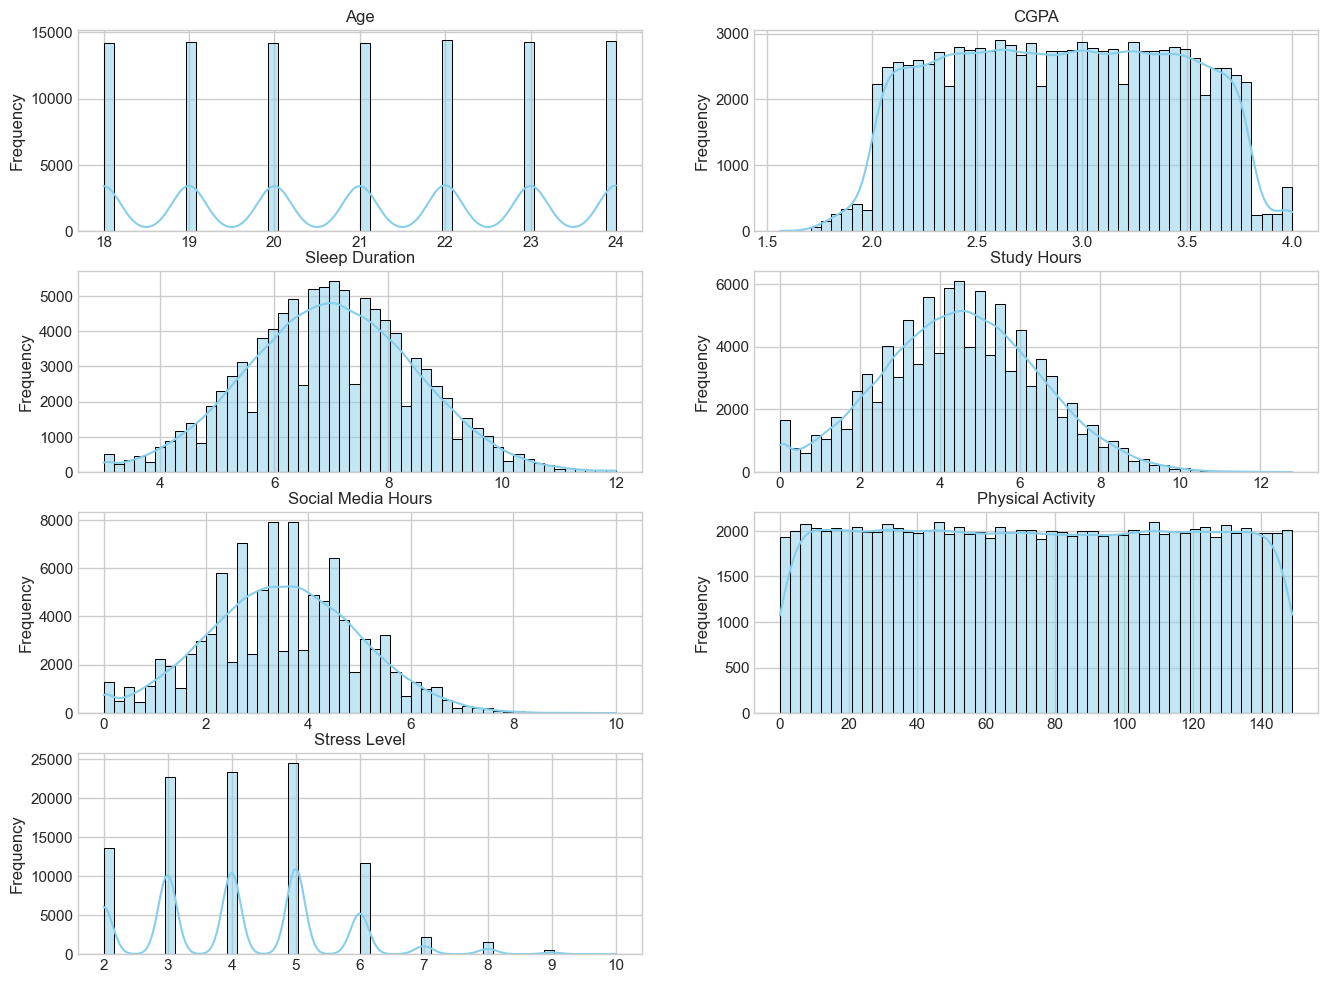

In [104]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(4, 2, 1)
sns.histplot(data=df, x ='Age', bins=50, kde=True, ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Age')
ax1.set_xlabel('')
ax1.set_ylabel('Frequency')

ax2 = plt.subplot(4, 2, 2)
sns.histplot(data=df, x ='CGPA', bins=50, kde=True, ax=ax2, color='skyblue', edgecolor='black')
ax2.set_title('CGPA')
ax2.set_xlabel('')
ax2.set_ylabel('Frequency')

ax3 = plt.subplot(4, 2, 3)
sns.histplot(data=df,x ='SD', bins=50, kde=True, ax=ax3, color='skyblue', edgecolor='black')
ax3.set_title('Sleep Duration')
ax3.set_xlabel('')
ax3.set_ylabel('Frequency')

ax4 = plt.subplot(4, 2, 4)
sns.histplot(data=df,x ='SH', bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.set_title('Study Hours')
ax4.set_xlabel('')
ax4.set_ylabel('Frequency')

ax5 = plt.subplot(4, 2, 5)
sns.histplot(data=df,x ='SMH', bins=50, kde=True, ax=ax5, color='skyblue', edgecolor='black')
ax5.set_title('Social Media Hours')
ax5.set_xlabel('')
ax5.set_ylabel('Frequency')

ax6 = plt.subplot(4, 2, 6)
sns.histplot(data=df,x ='PA', bins=50, kde=True, ax=ax6, color='skyblue', edgecolor='black')
ax6.set_title('Physical Activity')
ax6.set_xlabel('')
ax6.set_ylabel('Frequency')

ax7 = plt.subplot(4, 2, 7)
sns.histplot(data=df,x ='SL', bins=50, kde=True, ax=ax7, color='skyblue', edgecolor='black')
ax7.set_title('Stress Level')
ax7.set_xlabel('')
ax7.set_ylabel('Frequency')

plt.show()

По информации из графиков можно понять, что количество людей каждого возраста примерно одинаково, как и количество людей, занимающихся физической активностью то или иное время. Распределение Social Media Hours, Study Hours, Sleep Duration похожи на нормальное распределение

Построим круговые диаграммы для признаков Gender, Department и Depression

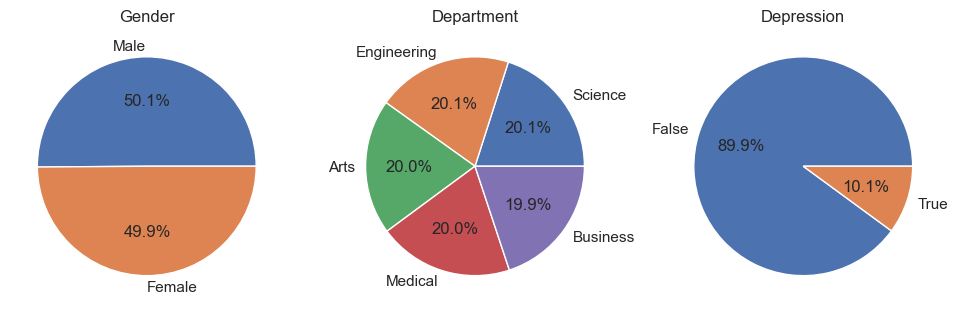

In [105]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
df['Gender'].value_counts().plot.pie(ax=axes[0], title='Gender', autopct='%1.1f%%')
axes[0].set_ylabel('')
df['Department'].value_counts().plot.pie(ax=axes[1], title='Department', autopct='%1.1f%%')
axes[1].set_ylabel('')
df['Depression'].value_counts().plot.pie(ax=axes[2], title='Depression', autopct='%1.1f%%')
axes[2].set_ylabel('')
plt.show()

На диаграммах видно, что количество женщин и мужчин почти совпадает, разделение по направлениям обучения практически одинаковое, а процент людей с депрессией составляет 10.1%

Построим ящики с усами для того, чтобы посмотреть на распределение значений, наличие выбросов

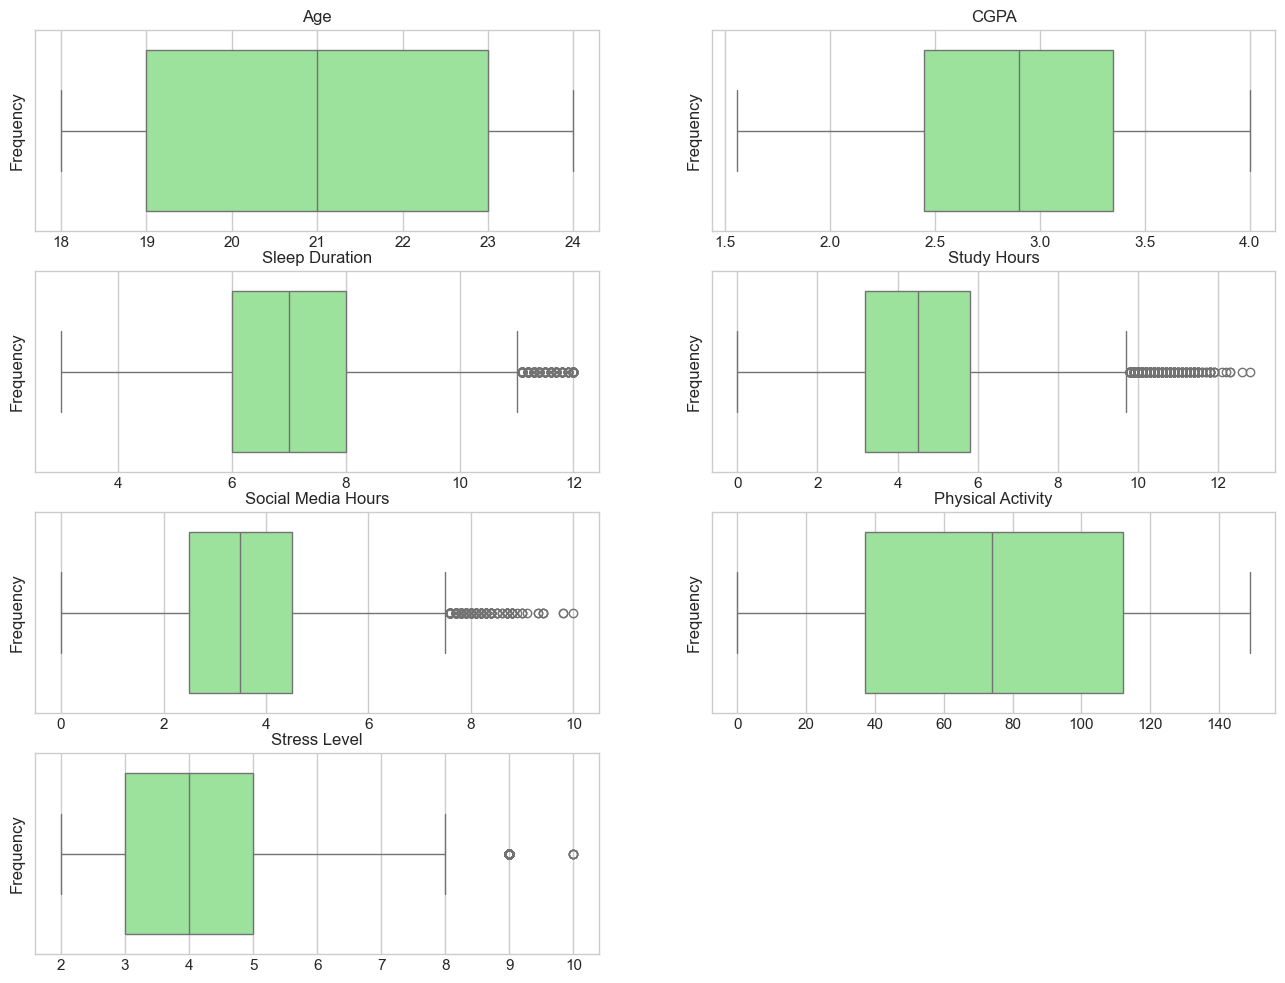

In [106]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(4, 2, 1)
sns.boxplot(data=df, x='Age', ax=ax1, color='lightgreen')
ax1.set_title('Age')
ax1.set_xlabel('')
ax1.set_ylabel('Frequency')

ax2 = plt.subplot(4, 2, 2)
sns.boxplot(data=df, x='CGPA', ax=ax2, color='lightgreen')
ax2.set_title('CGPA')
ax2.set_xlabel('')
ax2.set_ylabel('Frequency')

ax3 = plt.subplot(4, 2, 3)
sns.boxplot(data=df, x='SD', ax=ax3, color='lightgreen')
ax3.set_title('Sleep Duration')
ax3.set_xlabel('')
ax3.set_ylabel('Frequency')

ax4 = plt.subplot(4, 2, 4)
sns.boxplot(data=df, x='SH', ax=ax4, color='lightgreen')
ax4.set_title('Study Hours')
ax4.set_xlabel('')
ax4.set_ylabel('Frequency')

ax5 = plt.subplot(4, 2, 5)
sns.boxplot(data=df, x='SMH', ax=ax5, color='lightgreen')
ax5.set_title('Social Media Hours')
ax5.set_xlabel('')
ax5.set_ylabel('Frequency')

ax6 = plt.subplot(4, 2, 6)
sns.boxplot(data=df, x='PA', ax=ax6, color='lightgreen')
ax6.set_title('Physical Activity')
ax6.set_xlabel('')
ax6.set_ylabel('Frequency')

ax7 = plt.subplot(4, 2, 7)
sns.boxplot(data=df, x='SL', ax=ax7, color='lightgreen')
ax7.set_title('Stress Level')
ax7.set_xlabel('')
ax7.set_ylabel('Frequency')

plt.show()


Можно увидеть наличие выбросов у Stress Level, Social Media Hours, Study Hours и Sleep Duration

# Предобработка данных

Уберем выбросы и закодируем категориальные признаки с помощью one-hot encoder, при кодировке сразу удалим один из закодированных столбцов. Данные Depression переведем в int

In [8]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    col_data = df[col].dropna()
    if len(col_data) > 0:
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        mask = ~((df[col] < lower_bound) | (df[col] > upper_bound))
        df = df[mask]

cat_cols = df.select_dtypes(include=['object']).columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop ='first')
ohe_encoded_data = ohe.fit_transform(df[cat_cols])
ohe_df = pd.DataFrame(
    ohe_encoded_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)
df = df.drop(columns=cat_cols)
df = pd.concat([df, ohe_df], axis=1)
df['Depression'] = df['Depression'].astype(int)
df.head()

,Age,CGPA,SD,SH,SMH,PA,SL,Depression,Gender_Male,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,3.50,7.3,3.3,3.4,114,5,0,0.0,0.0,0.0,0.0,1.0
1,20,2.72,5.5,7.2,6.0,142,2,0,1.0,0.0,1.0,0.0,0.0
2,20,3.01,5.4,2.3,1.8,137,3,0,1.0,0.0,0.0,1.0,0.0
3,21,3.63,8.1,2.0,4.6,130,3,0,1.0,0.0,1.0,0.0,0.0
4,19,3.14,6.8,2.6,4.3,4,6,0,1.0,0.0,0.0,0.0,0.0


Посмотрим на Correlation Heatmap:

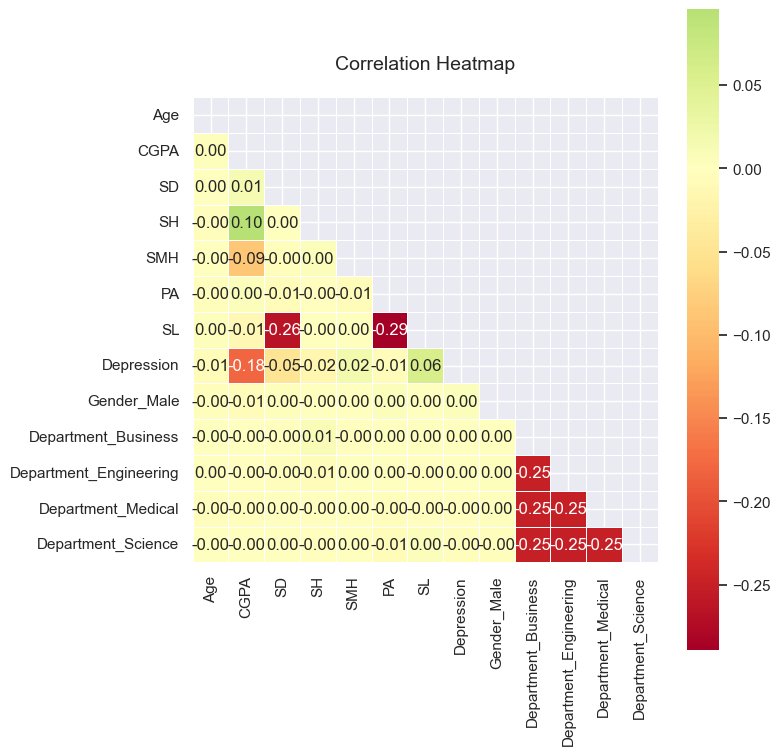

In [9]:
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr(method='pearson')
plt.figure(figsize=(8, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title(f'Correlation Heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


К сожалению, сильных корреляций между признаками нет - максимальная корреляция для CGPA с Depression(-0.18), Social Media Hours(-0.09) и Study Hours(0.10); для Depression с CGPA(-0.18), Sleep Duration(-0.05) и Stress Level(0.06) 

# Обучение Linear Regression для задачи регрессии

Обучим Linear Regrassion для задачи регрессии. Для этого поделим данные на три части - обучающие, валидационные и тестовые. Сделаем масштабирование признаков, обучим модель на обучающих данных. Затем сделаем прогнозы и оценим качество модели на всех трех частях данных

In [109]:
y = df['CGPA']
X = df.drop(columns=['CGPA'])
X1, X_test, y1, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
valid_metrics = evaluate_model(y_val, y_val_pred, "Valid")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")


 Метрики для Train:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0494
  MAPE: 16.12%

 Метрики для Valid:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0490
  MAPE: 16.15%

 Метрики для Test:
  MAE:  0.45
  RMSE: 0.52
  R²:   0.0440
  MAPE: 16.17%


MAE составляет 0.45, показывает среднюю абсолютную ошибку; RMSE - 0.52. показывает квадратный корень из средней квадратичной ошибки; R² - 0.04, gоказывает, насколько модель объясняет вариативность CGPA; MAPE - 16.17%, показывает среднюю абсолютную ошибку в процентах.
Из результатов, которые показывают метрики можно сделать вывод о том, что качесвто модели очень низкое. Также модель не переобучена, так как показатели метрик на обучающей, валидационной и тестовой выборке почти одинаковые

Попробуем заменить столбцы SH SD и SMH на один столбец - SH/(SH + SD + SMH) - этот столбец будет обозначать кпд каждого студента. Затем попробуем обучить модель ещё раз, но уже с новыми данными. 


In [110]:
new_df = df.copy()
new_df['Study_Efficiency'] = new_df['SH'] / (new_df['SH'] + new_df['SD'] + new_df['SMH'])
new_df = new_df.drop(columns=['SH', 'SD', 'SMH'])

y = new_df['CGPA']
X = new_df.drop(columns=['CGPA'])
X1, X_test, y1, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
valid_metrics = evaluate_model(y_val, y_val_pred, "Valid")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")


 Метрики для Train:
  MAE:  0.45
  RMSE: 0.52
  R²:   0.0415
  MAPE: 16.17%

 Метрики для Valid:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0413
  MAPE: 16.20%

 Метрики для Test:
  MAE:  0.45
  RMSE: 0.52
  R²:   0.0371
  MAPE: 16.22%


К сожалению, создание нового столбца не помогло модели, R² показывает ещё меньший результат. 

# Обучение Logistic Regression для задачи классификации

Обучим Logistic Regrassion для задачи регрессии. Для этого поделим данные на три части - обучающие, валидационные и тестовые. Сделаем масштабирование признаков, обучим модель на обучающих данных. Затем сделаем прогнозы и оценим качество модели на всех трех частях данных. Также поэксперементируем с числом эпох и значениями шага обучения

In [ ]:
y = df['Depression']
X = df.drop(columns=['Depression'])
X1, X_test, y1, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        print(f"\n Метрики для {dataset_name}:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-score:  {f1:.4f}")
        
        return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

for lr in [0.1, 0.01]: 
    print(f"\nШаг обучения: {lr}")
    for epochs in [50, 100, 200]:
        model = SGDClassifier(loss='log_loss', learning_rate='constant', 
                                    eta0=lr, max_iter=epochs, random_state=42, class_weight='balanced')
        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        y_val_pred = model.predict(X_val_scaled)
        y_test_pred = model.predict(X_test_scaled)
        print(f"\n Количество эпох: {epochs}")
        train_metrics = evaluate_model(y_train, y_train_pred, "Train")
        valid_metrics = evaluate_model(y_val, y_val_pred, "Valid")
        test_metrics = evaluate_model(y_test, y_test_pred, "Test")





Шаг обучения: 0.1

 Количество эпох: 50

 Метрики для Train:
  Accuracy:  0.5378
  Precision: 0.1120
  Recall:    0.5387
  F1-score:  0.1854

 Метрики для Valid:
  Accuracy:  0.5417
  Precision: 0.1242
  Recall:    0.5711
  F1-score:  0.2041

 Метрики для Test:
  Accuracy:  0.5365
  Precision: 0.1145
  Recall:    0.5372
  F1-score:  0.1887

 Количество эпох: 100

 Метрики для Train:
  Accuracy:  0.5378
  Precision: 0.1120
  Recall:    0.5387
  F1-score:  0.1854

 Метрики для Valid:
  Accuracy:  0.5417
  Precision: 0.1242
  Recall:    0.5711
  F1-score:  0.2041

 Метрики для Test:
  Accuracy:  0.5365
  Precision: 0.1145
  Recall:    0.5372
  F1-score:  0.1887

 Количество эпох: 200

 Метрики для Train:
  Accuracy:  0.5378
  Precision: 0.1120
  Recall:    0.5387
  F1-score:  0.1854

 Метрики для Valid:
  Accuracy:  0.5417
  Precision: 0.1242
  Recall:    0.5711
  F1-score:  0.2041

 Метрики для Test:
  Accuracy:  0.5365
  Precision: 0.1145
  Recall:    0.5372
  F1-score:  0.1887
Шаг обуч

Accuracy составляет в среднем 0.53(для шага обучения 0.1), показывает долю правильных классификаций.
Precision - 0.11, показывает долю верно классифицированных объектов среди всех объектов, которые к этому классу отнес классификатор. Низкое значение говорит о высоком уровне ложных срабатываний. 
Recall - 0.53, показывает отношение верно классифицированных объектов класса к общему числу элементов этого класса. Говорит о том, что модель часто не обнаруживает случаи депрессии, когда на самом деле она есть. 
F1 - 0.19, показывает среднее между Precision и Recall.

Из данных метрик можно сделать вывод, что модель плохо справляется со своей задачей. Также можно заметить, что несмотря на разное количество эпох(количество меняется от 50 до 200), результаты практически не меняются. При этом меньшее значение шага обучения положительно повлияло на модель - значение accuracy изменилось на 0.1, precision на 0.03, recall на 0.1, F1 на 0.08. Модель не переобучена, так как результаты для обучающих, валидационных и тестовых данных отличаются незначительно

Попробуем сделать вновь обучить модель на данных с измененным столбцом

In [25]:
new_df = df.copy()
new_df['Study_Efficiency'] = new_df['SH'] / (new_df['SH'] + new_df['SD'] + new_df['SMH'])
new_df = new_df.drop(columns=['SH', 'SD', 'SMH'])

y = new_df['Depression']
X = new_df.drop(columns=['Depression'])
X1, X_test, y1, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        print(f"\n Метрики для {dataset_name}:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-score:  {f1:.4f}")
        
        return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

for lr in [0.1, 0.01]: 
    print(f"\nШаг обучения: {lr}")
    for epochs in [50, 100, 200]:
        model = SGDClassifier(loss='log_loss', learning_rate='constant', 
                                    eta0=lr, max_iter=epochs, random_state=42, class_weight='balanced')
        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        y_val_pred = model.predict(X_val_scaled)
        y_test_pred = model.predict(X_test_scaled)
        print(f"\n Количество эпох: {epochs}")
        train_metrics = evaluate_model(y_train, y_train_pred, "Train")
        valid_metrics = evaluate_model(y_val, y_val_pred, "Valid")
        test_metrics = evaluate_model(y_test, y_test_pred, "Test")



Шаг обучения: 0.1

 Количество эпох: 50

 Метрики для Train:
  Accuracy:  0.6014
  Precision: 0.1416
  Recall:    0.6088
  F1-score:  0.2298

 Метрики для Valid:
  Accuracy:  0.6012
  Precision: 0.1510
  Recall:    0.6225
  F1-score:  0.2431

 Метрики для Test:
  Accuracy:  0.6027
  Precision: 0.1459
  Recall:    0.6096
  F1-score:  0.2355

 Количество эпох: 100

 Метрики для Train:
  Accuracy:  0.6014
  Precision: 0.1416
  Recall:    0.6088
  F1-score:  0.2298

 Метрики для Valid:
  Accuracy:  0.6012
  Precision: 0.1510
  Recall:    0.6225
  F1-score:  0.2431

 Метрики для Test:
  Accuracy:  0.6027
  Precision: 0.1459
  Recall:    0.6096
  F1-score:  0.2355

 Количество эпох: 200

 Метрики для Train:
  Accuracy:  0.6014
  Precision: 0.1416
  Recall:    0.6088
  F1-score:  0.2298

 Метрики для Valid:
  Accuracy:  0.6012
  Precision: 0.1510
  Recall:    0.6225
  F1-score:  0.2431

 Метрики для Test:
  Accuracy:  0.6027
  Precision: 0.1459
  Recall:    0.6096
  F1-score:  0.2355

Шаг об

В этот раз качество метрик немного улучшилось - accuracy увеличился в среднем на 0.05, precision на 0.02, recall на 0.08, F1 на 0.03. При изменении количества эпох значения не меняются, но при изменении шага обучения на меньший, результаты метрик ухудшились